# Business Analysis: E-Commerce Checkout A/B Test


# 1. Business Analysis Objective

The previous notebooks handled data quality, experiment validation, and statistical hypothesis testing.
This notebook takes those results and translates them into plain business terms.

The focus is on:

- **Customer conversion** — how many more users purchased under each variant
- **Additional purchasers** — what the observed difference looks like on a common user scale
- **Revenue per user** — the overall observed revenue impact per user
- **Checkout funnel** — where in the funnel the observed difference appears
- **Average Order Value (AOV)** — whether the typical order size changed
- **Payment failures** — whether the redesign affected failed payment attempts
- **Refund rate** — whether there were fewer refunds in one variant
- **Page performance** — how load time compared between variants
- **Segment-level differences** — how conversion looked across devices, user type, traffic source, and country
- **Business trade-offs** — a summary of the full picture, not just the primary metric


---

# 2. Load Data

The experiment dataset has one row per user.
Variant **A** is the existing (control) checkout. Variant **B** is the redesigned checkout.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH = Path("../Data/raw/ab_checkout_experiment_200k.csv")
df = pd.read_csv(DATA_PATH)

a = df[df["variant"] == "A"].copy()
b = df[df["variant"] == "B"].copy()

print(f"Total rows: {len(df):,}")
print(f"Variant A users: {len(a):,}")
print(f"Variant B users: {len(b):,}")
df.head()

Total rows: 200,000
Variant A users: 100,304
Variant B users: 99,696


,user_id,experiment_date,experiment_day,variant,device,country,traffic_source,new_user,sessions,checkout_started,purchase,revenue,payment_failed,refund,page_load_time_ms,exposure_logged
0,100001,2026-02-08,35,A,Desktop,AU,Organic,True,1,True,False,0.0000,False,False,2536.9000,True
1,100002,2026-01-07,3,B,Desktop,US,Organic,True,1,False,False,0.0000,False,False,2724.5000,True
2,100003,2026-02-09,36,A,Mobile,AU,Organic,True,1,True,False,0.0000,False,False,2746.7000,True
3,100004,2026-01-14,10,B,Mobile,CA,Paid Search,True,3,True,True,31.3900,False,False,2723.9000,True
4,100005,2026-01-09,5,B,Mobile,UK,Organic,True,9,False,False,0.0000,False,False,2540.0000,True


---

# 3. Executive Business Metrics

This table gives a quick side-by-side view of users, purchases, funnel steps, and revenue for both variants.

A few notes on the denominators:
- **Revenue per user** uses all users (including those with zero revenue).
- **AOV** uses only users who completed a purchase.
- **Checkout-to-purchase rate** uses checkout starters as the denominator.

These are different denominators, so the metrics measure different things and should not be mixed.

In [2]:
summary = df.groupby("variant").agg(
    users=("user_id", "count"),
    purchasers=("purchase", "sum"),
    checkout_started=("checkout_started", "sum"),
    total_revenue=("revenue", "sum"),
)

summary["purchase_conversion"] = summary["purchasers"] / summary["users"]
summary["checkout_start_rate"] = summary["checkout_started"] / summary["users"]
summary["checkout_to_purchase_rate"] = summary["purchasers"] / summary["checkout_started"]
summary["revenue_per_user"] = summary["total_revenue"] / summary["users"]

# AOV uses purchasers only as denominator
aov_by_variant = (
    df[df["purchase"]]
    .groupby("variant")["revenue"]
    .mean()
)
summary["aov"] = aov_by_variant

executive_summary = summary.reindex(["A", "B"])[
    [
        "users",
        "purchasers",
        "purchase_conversion",
        "checkout_started",
        "checkout_start_rate",
        "checkout_to_purchase_rate",
        "total_revenue",
        "revenue_per_user",
        "aov",
    ]
]

display(executive_summary)

,users,purchasers,purchase_conversion,checkout_started,checkout_start_rate,checkout_to_purchase_rate,total_revenue,revenue_per_user,aov
variant,,,,,,,,,
A,100304,9750,0.0972,29376,0.2929,0.3319,783037.5000,7.8066,80.3115
B,99696,10663,0.1070,28870,0.2896,0.3693,866468.4900,8.6911,81.2594


Across every revenue and conversion metric, Variant B shows a higher observed value.
The checkout start rate is the one exception — Variant B has a slightly lower rate, which will be examined more closely in Section 5.

---

# 4. Conversion Impact


In [3]:
conversion_A = summary.loc["A", "purchase_conversion"]
conversion_B = summary.loc["B", "purchase_conversion"]

conversion_difference = conversion_B - conversion_A
relative_lift = conversion_difference / conversion_A

# Translate to a 100,000-user scenario
users_per_scenario = 100_000
expected_A_purchasers = conversion_A * users_per_scenario
expected_B_purchasers = conversion_B * users_per_scenario
additional_purchasers = expected_B_purchasers - expected_A_purchasers

conversion_impact = pd.DataFrame(
    {
        "Measure": [
            "Conversion rate A",
            "Conversion rate B",
            "Absolute difference (B − A)",
            "Relative lift",
            "Expected purchasers per 100,000 under A",
            "Expected purchasers per 100,000 under B",
            "Additional purchasers per 100,000 (based on observed rates)",
        ],
        "Value": [
            f"{conversion_A:.2%}",
            f"{conversion_B:.2%}",
            f"+{conversion_difference:.2%} percentage points",
            f"+{relative_lift:.2%}",
            f"{expected_A_purchasers:,.0f}",
            f"{expected_B_purchasers:,.0f}",
            f"+{additional_purchasers:,.0f}",
        ],
    }
)

display(conversion_impact)

,Measure,Value
0,Conversion rate A,9.72%
1,Conversion rate B,10.70%
2,Absolute difference (B − A),+0.98% percentage points
3,Relative lift,+10.03%
4,"Expected purchasers per 100,000 under A","9,720"
5,"Expected purchasers per 100,000 under B","10,696"
6,"Additional purchasers per 100,000 (based on ob...",+975


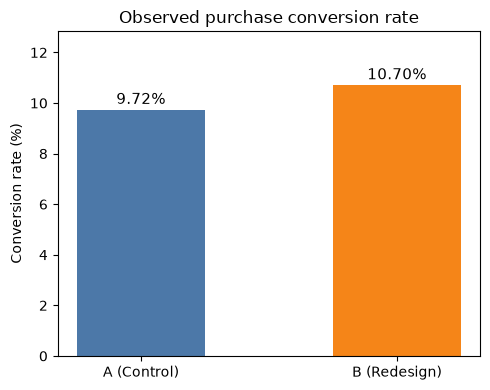

In [4]:
fig, axis = plt.subplots(figsize=(5, 4))
axis.bar(["A (Control)", "B (Redesign)"], [conversion_A * 100, conversion_B * 100],
         color=["#4C78A8", "#F58518"], width=0.5)
axis.set_title("Observed purchase conversion rate")
axis.set_ylabel("Conversion rate (%)")
axis.set_ylim(0, conversion_B * 100 * 1.2)
for i, val in enumerate([conversion_A, conversion_B]):
    axis.text(i, val * 100 + 0.1, f"{val:.2%}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

Based on the observed conversion rates, if 100,000 comparable users experienced each variant, Variant B would correspond to approximately **980 more purchasers** than Variant A.

This is a scenario calculation based on the observed experimental rates. It is not a guaranteed future outcome. The actual number may vary depending on the user population, time period, and other factors not captured in this experiment.

The 95% confidence interval from the statistical analysis in Notebook 03 was approximately **+0.71 to +1.24 percentage points**, which suggests the observed difference is unlikely to be due to random chance alone.

---

# 5. Checkout Funnel Business Analysis

The experiment funnel has three steps:

**Users → Started Checkout → Completed Purchase**

Looking at each step separately helps identify where the observed difference between A and B is happening — whether it is early (getting users to start checkout) or late (getting checkout starters to complete a purchase).

In [5]:
funnel_summary = executive_summary[
    [
        "users",
        "checkout_started",
        "checkout_start_rate",
        "purchasers",
        "purchase_conversion",
        "checkout_to_purchase_rate",
    ]
].copy()

display(funnel_summary)

,users,checkout_started,checkout_start_rate,purchasers,purchase_conversion,checkout_to_purchase_rate
variant,,,,,,
A,100304,29376,0.2929,9750,0.0972,0.3319
B,99696,28870,0.2896,10663,0.1070,0.3693


In [6]:
checkout_start_rate_A = summary.loc["A", "checkout_start_rate"]
checkout_start_rate_B = summary.loc["B", "checkout_start_rate"]
checkout_start_diff = checkout_start_rate_B - checkout_start_rate_A

checkout_to_purchase_A = summary.loc["A", "checkout_to_purchase_rate"]
checkout_to_purchase_B = summary.loc["B", "checkout_to_purchase_rate"]
checkout_to_purchase_diff = checkout_to_purchase_B - checkout_to_purchase_A
checkout_to_purchase_relative = checkout_to_purchase_diff / checkout_to_purchase_A

funnel_diff = pd.DataFrame(
    {
        "Metric": [
            "Checkout start rate A",
            "Checkout start rate B",
            "Checkout start rate difference (B − A)",
            "Statistical evidence (Notebook 03)",
            "Checkout-to-purchase rate A",
            "Checkout-to-purchase rate B",
            "Checkout-to-purchase difference (B − A)",
            "Checkout-to-purchase relative difference",
            "Statistical evidence (Notebook 03)",
        ],
        "Value": [
            f"{checkout_start_rate_A:.2%}",
            f"{checkout_start_rate_B:.2%}",
            f"{checkout_start_diff:+.2%} percentage points",
            "p ≈ 0.105 — insufficient evidence of a difference",
            f"{checkout_to_purchase_A:.2%}",
            f"{checkout_to_purchase_B:.2%}",
            f"{checkout_to_purchase_diff:+.2%} percentage points",
            f"{checkout_to_purchase_relative:+.2%}",
            "p ≈ 2.82e-21 — strong statistical evidence of a difference",
        ],
    }
)

display(funnel_diff)

,Metric,Value
0,Checkout start rate A,29.29%
1,Checkout start rate B,28.96%
2,Checkout start rate difference (B − A),-0.33% percentage points
3,Statistical evidence (Notebook 03),p ≈ 0.105 — insufficient evidence of a difference
4,Checkout-to-purchase rate A,33.19%
5,Checkout-to-purchase rate B,36.93%
6,Checkout-to-purchase difference (B − A),+3.74% percentage points
7,Checkout-to-purchase relative difference,+11.28%
8,Statistical evidence (Notebook 03),p ≈ 2.82e-21 — strong statistical evidence of ...


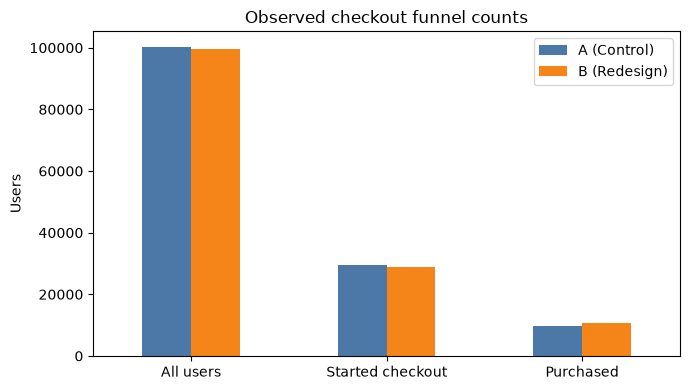

In [7]:
funnel_counts = funnel_summary[["users", "checkout_started", "purchasers"]].T
funnel_counts.columns = ["A (Control)", "B (Redesign)"]

funnel_counts.plot(kind="bar", figsize=(7, 4), color=["#4C78A8", "#F58518"])
plt.title("Observed checkout funnel counts")
plt.ylabel("Users")
plt.xticks(ticks=[0, 1, 2], labels=["All users", "Started checkout", "Purchased"], rotation=0)
plt.tight_layout()
plt.show()

The funnel shows an interesting pattern:

- **Checkout start rate** — Variant B had a slightly lower observed rate (−0.33 percentage points). The statistical analysis did not find sufficient evidence that this difference reflects a real treatment effect (p ≈ 0.105).
- **Checkout-to-purchase rate** — Variant B had a noticeably higher observed rate (+3.74 percentage points, approximately +11.28% relative). The statistical evidence here was very strong (p ≈ 2.82e-21).

The observed pattern suggests that **the main difference between A and B appears later in the checkout funnel**, after users have already started checkout — not in getting users to start checkout in the first place.

One interpretation is that the redesigned checkout experience may have made it easier for users who had already committed to starting checkout to complete their purchase. However, this is an observed pattern and not a standalone causal claim.

---

# 6. Revenue Impact

Revenue per user includes all experiment participants, including users who did not purchase (and therefore have zero revenue).
This makes it a useful user-level business metric, as it reflects the average revenue generated across the full user base — not just buyers.

In [8]:
revenue_a = a["revenue"].sum()
revenue_b = b["revenue"].sum()
revenue_difference = revenue_b - revenue_a

revenue_per_user_a = a["revenue"].mean()
revenue_per_user_b = b["revenue"].mean()
revenue_per_user_difference = revenue_per_user_b - revenue_per_user_a
revenue_per_user_relative = revenue_per_user_difference / revenue_per_user_a

# 100,000-user scenario
revenue_100k_a = revenue_per_user_a * users_per_scenario
revenue_100k_b = revenue_per_user_b * users_per_scenario
revenue_difference_100k = revenue_100k_b - revenue_100k_a

revenue_impact = pd.DataFrame(
    {
        "Measure": [
            "Total revenue A",
            "Total revenue B",
            "Total revenue difference (B − A)",
            "Revenue per user A",
            "Revenue per user B",
            "Revenue per user difference (B − A)",
            "Revenue per user relative difference",
            "Statistical evidence (Notebook 03)",
            "Revenue under A per 100,000 users (scenario)",
            "Revenue under B per 100,000 users (scenario)",
            "Revenue difference per 100,000 users (scenario)",
        ],
        "Value": [
            f"${revenue_a:,.2f}",
            f"${revenue_b:,.2f}",
            f"${revenue_difference:,.2f}",
            f"${revenue_per_user_a:,.4f}",
            f"${revenue_per_user_b:,.4f}",
            f"${revenue_per_user_difference:,.4f}",
            f"{revenue_per_user_relative:+.2%}",
            "p ≈ 4.50e-13 — strong statistical evidence of a difference",
            f"${revenue_100k_a:,.2f}",
            f"${revenue_100k_b:,.2f}",
            f"${revenue_difference_100k:,.2f}",
        ],
    }
)

display(revenue_impact)

,Measure,Value
0,Total revenue A,"$783,037.50"
1,Total revenue B,"$866,468.49"
2,Total revenue difference (B − A),"$83,430.99"
3,Revenue per user A,$7.8066
4,Revenue per user B,$8.6911
5,Revenue per user difference (B − A),$0.8845
6,Revenue per user relative difference,+11.33%
7,Statistical evidence (Notebook 03),p ≈ 4.50e-13 — strong statistical evidence of ...
8,"Revenue under A per 100,000 users (scenario)","$780,664.28"
9,"Revenue under B per 100,000 users (scenario)","$869,110.59"


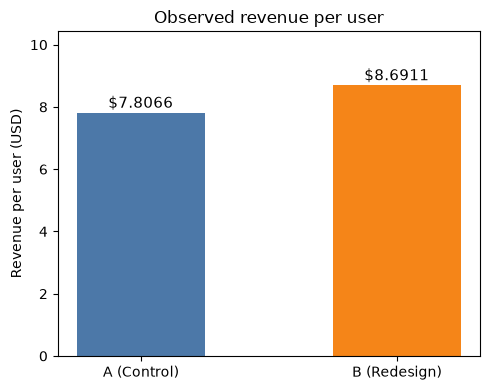

In [9]:
fig, axis = plt.subplots(figsize=(5, 4))
axis.bar(["A (Control)", "B (Redesign)"], [revenue_per_user_a, revenue_per_user_b],
         color=["#4C78A8", "#F58518"], width=0.5)
axis.set_title("Observed revenue per user")
axis.set_ylabel("Revenue per user (USD)")
axis.set_ylim(0, revenue_per_user_b * 1.2)
for i, val in enumerate([revenue_per_user_a, revenue_per_user_b]):
    axis.text(i, val + 0.05, f"${val:.4f}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

Based on the observed revenue per user, a scenario with 100,000 users under each variant would correspond to approximately **\$88,450 more revenue under Variant B** than under Variant A.

This is a scenario calculation — it simply scales the observed revenue per user to a common reference point. It is not a forecast and does not guarantee the same difference will continue outside this experiment.

The Mann-Whitney test in Notebook 03 found strong statistical evidence that the revenue distributions differ between variants (p ≈ 4.50e-13).

---

# 7. Average Order Value

AOV (Average Order Value) measures the average revenue per completed purchase.
It is calculated only among users who purchased — users with zero revenue are excluded from this metric.

This is a different question from revenue per user: it asks about the size of each individual order, not the overall revenue across all users.

In [10]:
aov_a = a.loc[a["purchase"], "revenue"].mean()
aov_b = b.loc[b["purchase"], "revenue"].mean()
aov_difference = aov_b - aov_a
aov_relative = aov_difference / aov_a

aov_summary = pd.DataFrame(
    {
        "Measure": [
            "AOV A (purchasers only)",
            "AOV B (purchasers only)",
            "AOV difference (B − A)",
            "AOV relative difference",
            "Statistical evidence (Notebook 03)",
        ],
        "Value": [
            f"${aov_a:,.4f}",
            f"${aov_b:,.4f}",
            f"${aov_difference:,.4f}",
            f"{aov_relative:+.2%}",
            "p ≈ 0.407 — insufficient evidence of a difference",
        ],
    }
)

display(aov_summary)

,Measure,Value
0,AOV A (purchasers only),$80.3115
1,AOV B (purchasers only),$81.2594
2,AOV difference (B − A),$0.9478
3,AOV relative difference,+1.18%
4,Statistical evidence (Notebook 03),p ≈ 0.407 — insufficient evidence of a difference


The observed AOV was slightly higher in Variant B (approximately \$81.26 vs \$80.31, a difference of about \$0.95).

However, **the statistical analysis in Notebook 03 did not provide sufficient evidence of a meaningful distributional difference in AOV** (Mann-Whitney p ≈ 0.407).

This means the observed difference could plausibly be explained by random variation alone. It would not be appropriate to say that Variant B increases AOV based on this evidence.

The higher revenue per user in Variant B is more likely driven by the higher purchase conversion rate (more users purchasing), not by individual orders being larger.

---

# 8. Guardrail Business Analysis

Guardrails check for possible trade-offs. Even if the primary metric improves, a new design could create problems in other areas — such as more payment failures, more refunds, or slower pages.

The guardrail results from Notebook 03 are examined here in business terms.

## 8.1 Payment Failure Rate

Payment failure rate is calculated among checkout starters — users who started the checkout process but whose payment attempt failed.

In [11]:
checkout_a = a[a["checkout_started"]]
checkout_b = b[b["checkout_started"]]

payment_fail_rate_a = checkout_a["payment_failed"].mean()
payment_fail_rate_b = checkout_b["payment_failed"].mean()
payment_fail_diff = payment_fail_rate_b - payment_fail_rate_a

payment_fail_summary = pd.DataFrame(
    {
        "Measure": [
            "Payment failure rate A (among checkout starters)",
            "Payment failure rate B (among checkout starters)",
            "Difference (B − A)",
            "Statistical evidence (Notebook 03)",
        ],
        "Value": [
            f"{payment_fail_rate_a:.2%}",
            f"{payment_fail_rate_b:.2%}",
            f"{payment_fail_diff:+.2%} percentage points",
            "p ≈ 0.272 — insufficient evidence of a difference",
        ],
    }
)

display(payment_fail_summary)

,Measure,Value
0,Payment failure rate A (among checkout starters),2.26%
1,Payment failure rate B (among checkout starters),2.13%
2,Difference (B − A),-0.13% percentage points
3,Statistical evidence (Notebook 03),p ≈ 0.272 — insufficient evidence of a difference


Variant B had a slightly lower observed payment failure rate (approximately 2.13% vs 2.26%, a difference of −0.13 percentage points).

However, the statistical analysis did not find sufficient evidence to conclude that the variants differ on this metric (p ≈ 0.272). The observed difference could plausibly be due to random variation.

**Business interpretation:** There is no observed evidence that the redesigned checkout worsened payment reliability. The guardrail was not triggered.

## 8.2 Refund Rate

Refund rate is calculated among users who completed a purchase.

In [12]:
buyers_a = a[a["purchase"]]
buyers_b = b[b["purchase"]]

refund_rate_a = buyers_a["refund"].mean()
refund_rate_b = buyers_b["refund"].mean()
refund_diff = refund_rate_b - refund_rate_a

refund_summary = pd.DataFrame(
    {
        "Measure": [
            "Refund rate A (among purchasers)",
            "Refund rate B (among purchasers)",
            "Difference (B − A)",
            "Statistical evidence (Notebook 03)",
        ],
        "Value": [
            f"{refund_rate_a:.2%}",
            f"{refund_rate_b:.2%}",
            f"{refund_diff:+.2%} percentage points",
            "p ≈ 0.0278 — statistical evidence of a difference",
        ],
    }
)

display(refund_summary)

,Measure,Value
0,Refund rate A (among purchasers),5.65%
1,Refund rate B (among purchasers),4.96%
2,Difference (B − A),-0.69% percentage points
3,Statistical evidence (Notebook 03),p ≈ 0.0278 — statistical evidence of a difference


Variant B had a lower observed refund rate (approximately 4.96% vs 5.65%, a difference of −0.69 percentage points).
The statistical test in Notebook 03 found evidence that the variants differ on this metric (p ≈ 0.0278).

**Business interpretation:** Fewer purchasers in Variant B requested refunds. A lower refund rate is generally favourable — it could suggest that users who purchased under the redesigned checkout were more satisfied with their decision.

However, it would be premature to automatically attribute the lower refund rate to the checkout redesign. Refund behaviour can be influenced by many factors not measured in this experiment (e.g., product type, customer service interactions, order value). The finding is encouraging, but should be interpreted with care.

## 8.3 Page Load Time

Page load time measures how long the checkout page took to load for users in each variant.

In [13]:
avg_load_a = a["page_load_time_ms"].mean()
avg_load_b = b["page_load_time_ms"].mean()
load_diff_ms = avg_load_b - avg_load_a
load_relative = load_diff_ms / avg_load_a

median_load_a = a["page_load_time_ms"].median()
median_load_b = b["page_load_time_ms"].median()
median_diff_ms = median_load_b - median_load_a

load_summary = pd.DataFrame(
    {
        "Measure": [
            "Mean page load time A (ms)",
            "Mean page load time B (ms)",
            "Mean difference (B − A)",
            "Relative difference",
            "Median page load time A (ms)",
            "Median page load time B (ms)",
            "Median difference (B − A)",
            "Statistical evidence (Notebook 03)",
        ],
        "Value": [
            f"{avg_load_a:,.2f} ms",
            f"{avg_load_b:,.2f} ms",
            f"{load_diff_ms:,.2f} ms",
            f"{load_relative:+.2%}",
            f"{median_load_a:,.2f} ms",
            f"{median_load_b:,.2f} ms",
            f"{median_diff_ms:,.2f} ms",
            "p very small — statistically significant difference detected",
        ],
    }
)

display(load_summary)

,Measure,Value
0,Mean page load time A (ms),"2,839.96 ms"
1,Mean page load time B (ms),"2,771.04 ms"
2,Mean difference (B − A),-68.92 ms
3,Relative difference,-2.43%
4,Median page load time A (ms),"2,798.20 ms"
5,Median page load time B (ms),"2,728.70 ms"
6,Median difference (B − A),-69.50 ms
7,Statistical evidence (Notebook 03),p very small — statistically significant diffe...


Variant B had a lower observed mean page load time — approximately 69 ms lower than Variant A (around 2,771 ms vs 2,840 ms).

The Mann-Whitney test in Notebook 03 produced a very small p-value, indicating strong statistical evidence that the load time distributions differ.

**Business interpretation:** Variant B loaded slightly faster. A 69 ms difference is relatively small in absolute terms — users are unlikely to notice a change of under 100 ms in most contexts. With a dataset of 200,000 users, even small differences can reach statistical significance.

The important point here is that page performance did **not** worsen under the redesign. This is a positive guardrail result — the redesigned checkout appears to load at least as fast as the original.

---

# 9. Customer / Segment Analysis

This section compares observed conversion rates between A and B across four simple segments:
device type, new vs returning users, traffic source, and country.

These comparisons are **exploratory**. A larger observed difference in a segment does not automatically mean a real treatment effect — especially in smaller segments where random variation has more influence.

No separate hypothesis tests are run for individual segments in this notebook.

In [14]:
# Helper: pivot a segment groupby into a readable A vs B table
def segment_table(group_col):
    seg = (
        df.groupby([group_col, "variant"])["purchase"]
        .mean()
        .reset_index()
        .pivot(index=group_col, columns="variant", values="purchase")
        .reindex(columns=["A", "B"])
    )
    seg.columns.name = None
    seg["Diff (B−A) pp"] = seg["B"] - seg["A"]
    seg["A"] = seg["A"].map("{:.2%}".format)
    seg["B"] = seg["B"].map("{:.2%}".format)
    seg["Diff (B−A) pp"] = seg["Diff (B−A) pp"].map("{:+.2%}".format)
    return seg

print("=== Conversion by Device ===")
display(segment_table("device"))

=== Conversion by Device ===


,A,B,Diff (B−A) pp
device,,,
Desktop,10.77%,11.63%,+0.86%
Mobile,9.29%,10.32%,+1.03%
Tablet,7.98%,9.04%,+1.06%


In [15]:
print("=== Conversion by New vs Returning User ===")
seg_new = (
    df.groupby(["new_user", "variant"])["purchase"]
    .mean()
    .reset_index()
    .pivot(index="new_user", columns="variant", values="purchase")
    .reindex(columns=["A", "B"])
)
seg_new.columns.name = None
seg_new.index = seg_new.index.map({True: "New user", False: "Returning user"})
seg_new["Diff (B−A) pp"] = seg_new["B"] - seg_new["A"]
seg_new["A"] = seg_new["A"].map("{:.2%}".format)
seg_new["B"] = seg_new["B"].map("{:.2%}".format)
seg_new["Diff (B−A) pp"] = seg_new["Diff (B−A) pp"].map("{:+.2%}".format)
display(seg_new)

=== Conversion by New vs Returning User ===


,A,B,Diff (B−A) pp
new_user,,,
Returning user,11.74%,13.03%,+1.30%
New user,8.31%,9.07%,+0.76%


In [16]:
print("=== Conversion by Traffic Source ===")
display(segment_table("traffic_source"))

=== Conversion by Traffic Source ===


,A,B,Diff (B−A) pp
traffic_source,,,
Email,11.74%,13.33%,+1.59%
Organic,10.40%,11.40%,+0.99%
Paid Search,8.70%,9.53%,+0.83%
Referral,10.22%,11.94%,+1.72%
Social,8.30%,8.74%,+0.43%


In [17]:
print("=== Conversion by Country ===")
display(segment_table("country"))

=== Conversion by Country ===


,A,B,Diff (B−A) pp
country,,,
AU,10.41%,10.91%,+0.50%
CA,10.32%,11.03%,+0.71%
DE,9.71%,10.84%,+1.13%
IN,9.27%,10.02%,+0.74%
Other,9.67%,10.61%,+0.94%
UK,9.86%,11.10%,+1.24%
US,9.64%,10.75%,+1.11%


**How to read these tables:** Each row shows the observed purchase conversion rate for Variant A and Variant B within that segment, along with the difference in percentage points.

**Key observations:**
- Variant B shows a higher observed conversion rate across most segments.
- The size of the difference varies by segment — some segments appear to show a larger gap than others.
- These differences should be treated as **exploratory observations**, not confirmed treatment effects.

Segment-level differences can arise from:
- Random variation (especially in smaller segments)
- Imbalances not fully visible in the experiment
- Real heterogeneity in how different user groups respond to the checkout redesign

If any segment shows a particularly large or unexpected difference, that could be a useful direction for further targeted analysis — but those findings should be treated as hypotheses to be tested separately, not conclusions from this experiment.

---

# 10. Business Trade-offs

This table summarises the main observed results across all metrics and their business meaning.
The language is intentionally factual. The final launch or rollout decision is not made here.

| Area | Observed result | Business meaning |
|---|---|---|
| Purchase conversion | B higher (+0.98 pp, +10.03% relative) | More observed purchasers under B |
| Checkout start rate | B slightly lower (−0.33 pp) | Slightly fewer users started checkout under B; difference not statistically established |
| Checkout-to-purchase rate | B higher (+3.74 pp, +11.28% relative) | More checkout starters completed a purchase under B |
| Revenue per user | B higher (+\$0.88, +11.33% relative) | Higher observed revenue per user under B |
| AOV | B slightly higher (+\$0.95, +1.18% relative) | Difference not statistically established (p ≈ 0.407) |
| Payment failure rate | B slightly lower (−0.13 pp) | No statistically established difference (p ≈ 0.272) |
| Refund rate | B lower (−0.69 pp) | Statistical evidence of a difference (p ≈ 0.028); fewer refunds under B |
| Page load time | B faster (−69 ms, −2.43%) | B loaded slightly faster; no performance regression under the redesign |

---

# 11. Business Scenario Calculation

To make the observed results easier to reason about, the key metrics are scaled to a common **100,000-user scenario**.

These numbers are not forecasts. They simply translate the observed experimental differences into a shared reference scale.

In [18]:
# All scenario values use users_per_scenario = 100,000 defined in Section 4
scenario_purchasers_a = conversion_A * users_per_scenario
scenario_purchasers_b = conversion_B * users_per_scenario
scenario_purchasers_diff = scenario_purchasers_b - scenario_purchasers_a

scenario_revenue_a = revenue_per_user_a * users_per_scenario
scenario_revenue_b = revenue_per_user_b * users_per_scenario
scenario_revenue_diff = scenario_revenue_b - scenario_revenue_a

scenario = pd.DataFrame(
    {
        "Metric": [
            "Purchasers under A",
            "Purchasers under B",
            "Additional purchasers (B − A)",
            "Revenue under A",
            "Revenue under B",
            "Revenue difference (B − A)",
        ],
        f"Per {users_per_scenario:,} users (scenario)": [
            f"{scenario_purchasers_a:,.0f}",
            f"{scenario_purchasers_b:,.0f}",
            f"+{scenario_purchasers_diff:,.0f}",
            f"${scenario_revenue_a:,.2f}",
            f"${scenario_revenue_b:,.2f}",
            f"+${scenario_revenue_diff:,.2f}",
        ],
    }
)

display(scenario)

,Metric,"Per 100,000 users (scenario)"
0,Purchasers under A,"9,720"
1,Purchasers under B,"10,696"
2,Additional purchasers (B − A),+975
3,Revenue under A,"$780,664.28"
4,Revenue under B,"$869,110.59"
5,Revenue difference (B − A),"+$88,446.31"


**Interpreting the scenario:**

If the observed conversion and revenue rates from this experiment were applied to a future group of 100,000 users:
- Variant B would be associated with approximately **~980 more purchasers**.
- Variant B would be associated with approximately **~\$88,450 more revenue**.

These figures are based on the observed experimental rates. Actual future performance may differ due to seasonal effects, changes in the user population, product changes, or other factors outside the experiment. This scenario calculation is a communication tool, not a financial projection.

---

# 12. Key Business Findings


The following points summarise the key observed facts from this business analysis. Each point is based on the experimental data and the statistical results from Notebook 03.

* Variant B had a higher observed purchase conversion rate: **10.70% vs 9.72%**, an absolute difference of **+0.98 percentage points**.

* The observed relative lift in purchase conversion was approximately **+10.03%**.

* The 95% confidence interval for the conversion difference was approximately **+0.71 to +1.24 percentage points**. Since the interval does not include zero, this is consistent with the statistical evidence of a difference found in the hypothesis test.

* The checkout start rate was slightly lower in Variant B (**−0.33 percentage points**), but this difference was **not statistically established** (p ≈ 0.105).

* The checkout-to-purchase rate was notably higher in Variant B (**+3.74 percentage points**, approximately **+11.28% relative**), with strong statistical evidence of a difference (p ≈ 2.82e-21). The observed difference in conversion is concentrated in this later stage of the checkout funnel.

* Revenue per user was higher in Variant B (**+$0.88**, approximately **+11.33% relative**), with strong statistical evidence of a distributional difference (Mann-Whitney p ≈ 4.50e-13).

* The AOV difference was relatively small (**+$0.95**) and **not statistically established** (Mann-Whitney p ≈ 0.407). Therefore, it is not appropriate to conclude that the redesign increased AOV.

* The payment failure rate difference was **not statistically established** (p ≈ 0.272). There was no statistically established difference in payment failure rate between the variants.

* Variant B had a lower observed refund rate (**4.96% vs 5.65%**), with statistical evidence of a difference (p ≈ 0.028). The observed refund rate was lower under Variant B.

* Page load time was approximately **69 ms lower** in Variant B (**−2.43%**). The analysis did not show an observed performance regression under the redesigned checkout.
